# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons selectionnés : -appid -name - release_date -required_age -price - dlc_count -metacritic_score -achievements -recommendations -categories -positive -negative -median_playtime_forever -peak_ccu -pct_pos_total

### Notre objectives


## Importation des librairies et du dataset

In [57]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")


## Prétraitement des données


In [58]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Supprimer les jeux sans recommandations
df = df[df['metacritic_score'] > 0]
## Garder que 500 jeux avec le plus de recommandations
df = df.nlargest(500, 'metacritic_score')

## Supprimer 'positif' et 'negative' car redondant avec 'pct_pos_total'
df = df.drop(columns=['positive', 'negative'])

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])

# Verifier les modifications
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])
df.head(10)

Number of samples: 500
Number of features: 14


,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
171,Disco Elysium - The Final Cut,2019,0,39.99,2,97,45,98796,459,1727,93,98950,1,0
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,7101,117698,87,1803832,1,1
16,Baldur's Gate 3,2023,17,59.99,2,96,54,647659,5712,48021,96,648637,1,1
12,ELDEN RING,2022,16,59.99,2,94,42,749109,5675,46121,92,749606,1,1
89,The Elder Scrolls V: Skyrim,2011,17,19.99,1,94,75,181083,0,2380,94,181095,1,0
160,BioShock Infinite,2013,17,29.99,5,94,80,104602,612,320,93,104626,1,0
724,Divinity: Original Sin - Enhanced Edition,2015,0,39.99,1,94,54,23450,393,1106,89,23474,1,1
3074,Cobalt Core,2023,0,19.99,1,94,15,3153,524,106,96,3155,1,0
14851,Mass Effect 2 (2010) Edition,2023,17,29.99,0,94,0,190,0,18,73,190,1,0
11,The Witcher 3: Wild Hunt,2015,17,39.99,22,93,78,761658,927,15129,96,751939,1,0


## Exploration des données

Features: ['release_year', 'required_age', 'price', 'dlc_count', 'metacritic_score', 'achievements', 'recommendations', 'median_playtime_forever', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'single_player', 'multi_player']


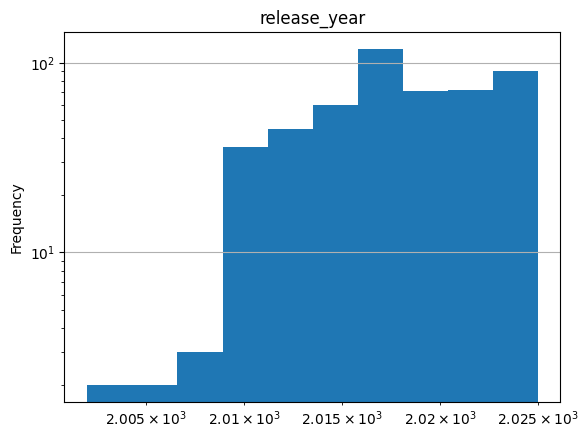

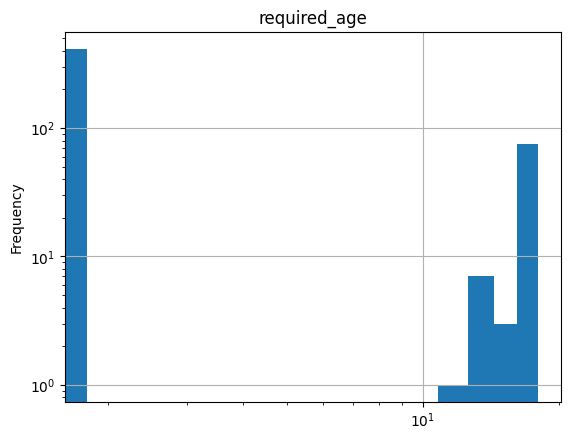

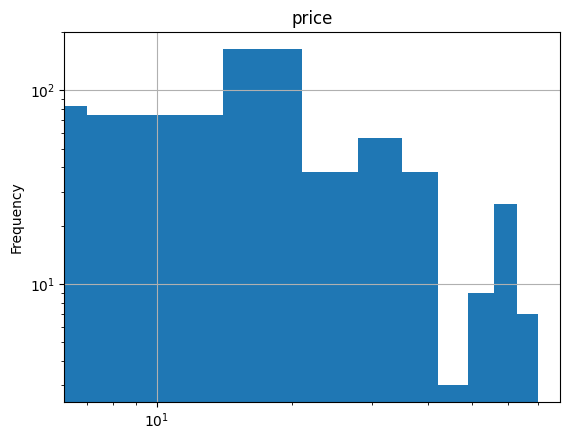

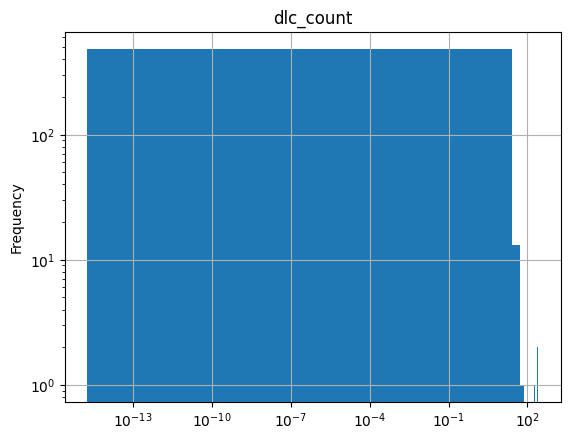

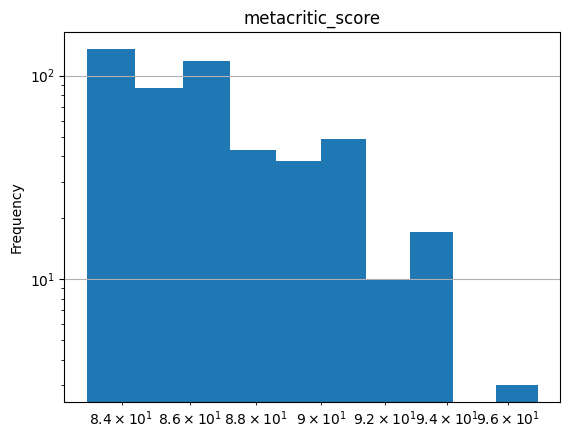

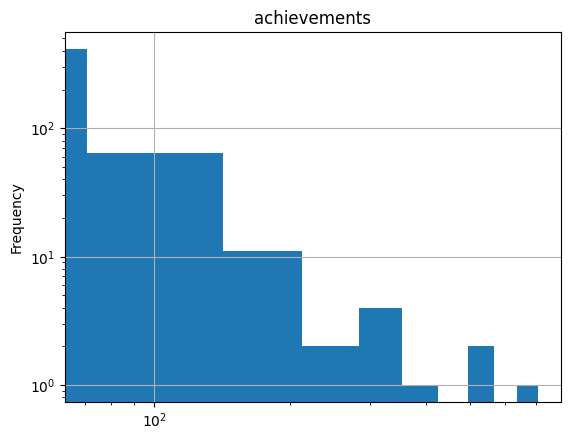

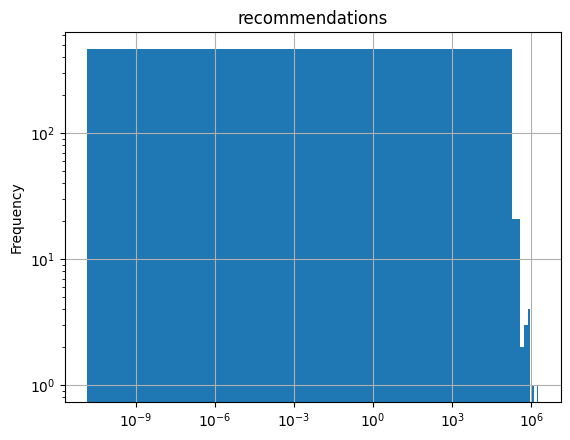

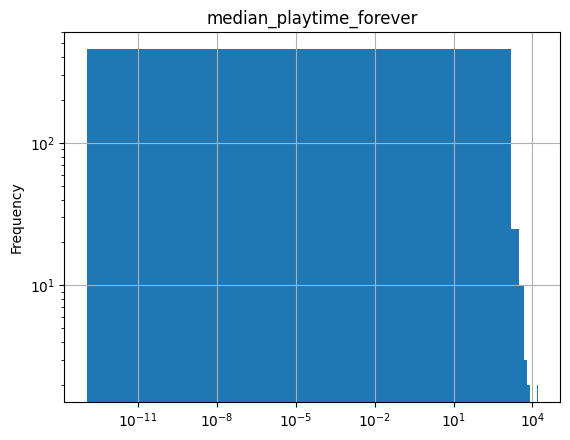

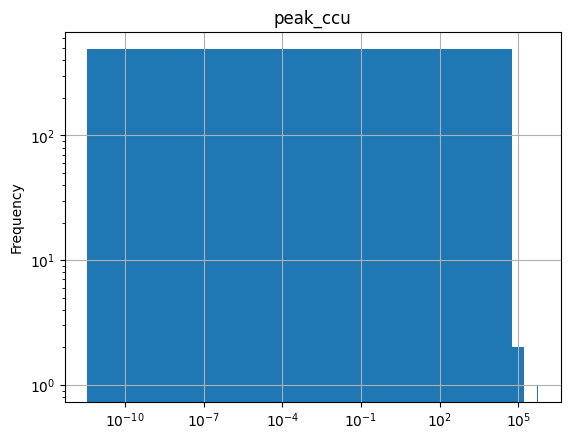

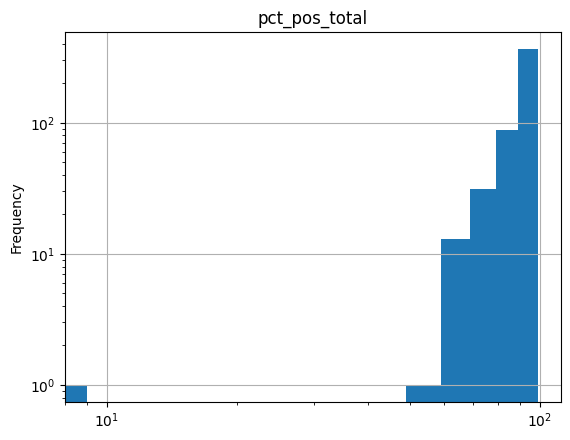

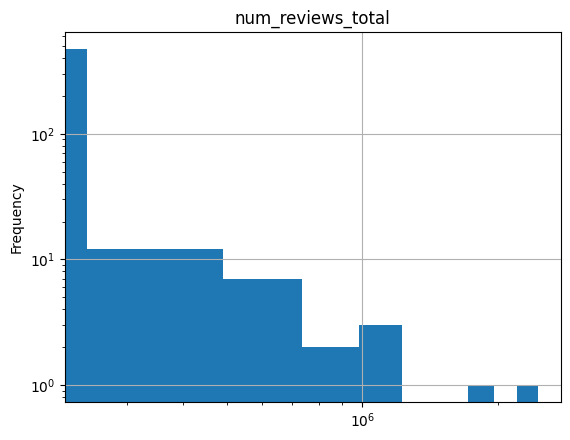

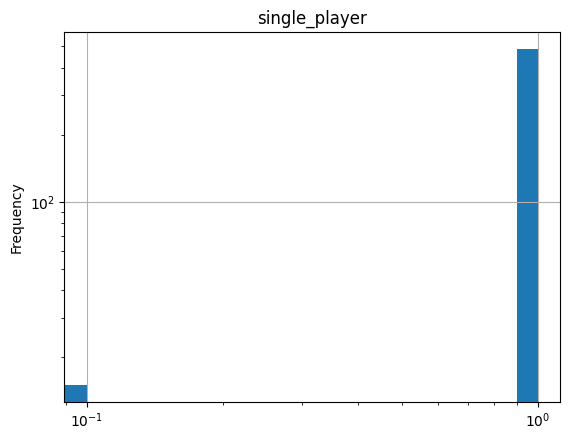

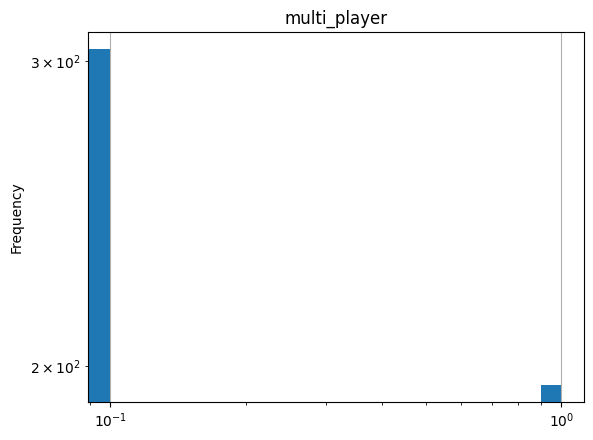

In [59]:
# Distribution des données
# For the columns with numbers, we can plot the histograms
# features=['release_year', 'required_age', 'price', 'metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']
# extract column names (numeric only to plot histograms)  
features = df.select_dtypes(include='number').columns.tolist()
print("Features:", features)

#histogrammes
for x in features:
  plt.figure()
  df[x].plot.hist(loglog=True)
  plt.title(x)
  plt.grid()
#même en affichant les données sous l'échelle logarithmique, on observe déjà des pics au niveau de 0 pour les données manquantes(le dataset n'est pas complet)

# #covariance & correlation
# df2=df[['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']]
# df2.corr() 
# #on observe qu'il y a qlq redondances dans notre jeux de données, les catégories recommendations, positive et num_reviews_total ont une correlation au dessus de 0.9.

# df.plot.scatter(x='peak_ccu',y='metacritic_score')
# df.plot.scatter(x='metacritic_score',y='recommendations')
# df.plot.scatter(x='positive',y='median_playtime_forever')
# #en testant qlq combinaisons de catégories en x et y (en évitant de prendre des catégories trop redondantes), 
# # on observe que les données ne se regroupe pas bien, se répartissant plus selon l'absence de données que formant des clusters cohérents

# df.sort_values("negative", ascending=False).head(1)


In [60]:
#we search for how much features are missing

missing = df.eq(0).sum()
lenght= len(df)
print(missing)
print("lenght total du data set =",lenght)

#on observe que beaucoup de données sont manquante sur ce dataset, en particulier sur les petits jeux qui représentent la majorité des sorties steam.

name                         0
release_year                 0
required_age               413
price                       30
dlc_count                  169
metacritic_score             0
achievements                68
recommendations             15
median_playtime_forever    205
peak_ccu                    37
pct_pos_total                0
num_reviews_total            0
single_player               15
multi_player               305
dtype: int64
lenght total du data set = 500


In [61]:
# Supprimer l'outlier pour tester
# df = df[df['name'] != 'Counter-Strike 2']

In [62]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

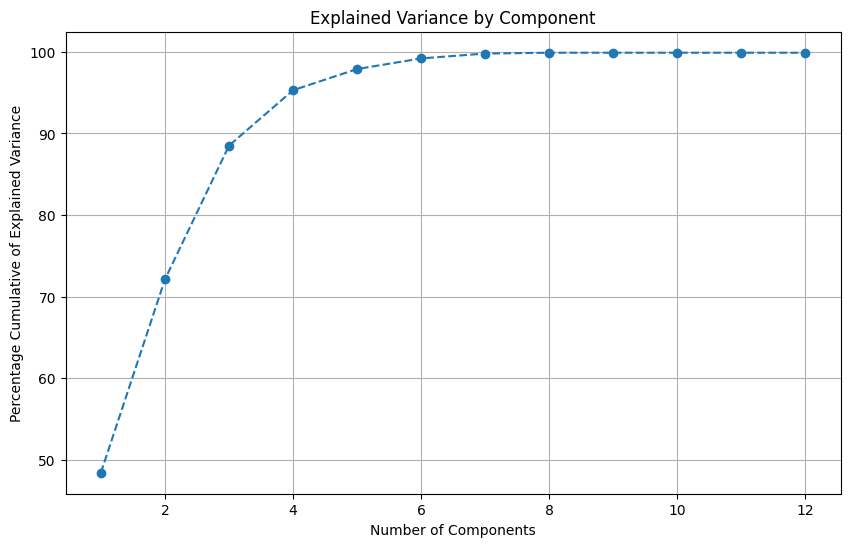

In [63]:
from sklearn.preprocessing import Normalizer

data = df.drop(columns=['name', 'release_year'])

df_normalized = Normalizer().fit_transform(data.values)
# print(df_normalized.shape)
# print(df_normalized)
pca = PCA()
pca.fit(df_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

In [ ]:
pca = PCA(n_components = 3)
pca.fit(df_normalized)

data_pca = pca.transform(df_normalized)
df_reduced = pd.DataFrame(data_pca, columns = ['PCA1', 'PCA2', 'PCA3'])
df_reduced.insert(0, "name", df['name'])
df_reduced.head(10)

## Visualisation 2D 
# plt.figure(figsize=(10,6))
# for i, txt in enumerate(df_reduced['name']):
#     plt.annotate(txt, (df_reduced['PCA1'][i], df_reduced['PCA2'][i]), fontsize=8, alpha=0.6)
# Coloring by recommendations
# scatter = plt.scatter(df_reduced['PCA1'], df_reduced['PCA2'], c=df['recommendations'], cmap='viridis', alpha=0.7)
# cbar = plt.colorbar(scatter)
# cbar.set_label('Number of Recommendations')
# plt.title("PCA of Steam Games Dataset")
# plt.xlabel("PCA1")
# plt.ylabel("PCA2")
# plt.grid()
# plt.show()

# Visualisation 3D
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_reduced['PCA1'], df_reduced['PCA2'], data_pca[:,2], c=df['recommendations'], cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Recommendations')
ax.set_title("3D PCA of Steam Games Dataset")
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
plt.show()



ValueError: Shape of passed values is (500, 3), indices imply (500, 2)

In [65]:
feature_names = data.columns

# Matrice des loadings (composantes)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

print(loadings)

                              PC1       PC2
required_age            -0.000833 -0.000856
price                   -0.050153 -0.027859
dlc_count               -0.005299 -0.002905
metacritic_score        -0.468202 -0.280285
achievements            -0.138475 -0.056891
recommendations          0.674081  0.079747
median_playtime_forever -0.280510  0.882433
peak_ccu                -0.017224  0.007631
pct_pos_total           -0.410057 -0.271629
num_reviews_total        0.239835 -0.241906
single_player           -0.005238 -0.003098
multi_player            -0.002207 -0.001456


[[ 9.90614784e-02 -1.34625031e-02]
 [ 9.87789920e-02 -1.30257337e-02]
 [ 9.72647892e-02 -1.00685972e-02]
 [ 9.80867277e-02 -1.08489629e-02]
 [ 1.00578683e-01 -1.60372676e-02]
 [ 9.92630156e-02 -1.26275971e-02]
 [ 9.39716964e-02 -6.87614881e-03]
 [ 4.38089116e-02  7.59943105e-02]
 [-2.14959969e-01 -1.63334072e-01]
 [ 1.02461233e-01 -1.35919171e-02]
 [ 9.95366062e-02 -1.55941017e-02]
 [ 9.95565342e-02 -1.27250932e-02]
 [ 9.94522598e-02 -1.61147638e-02]
 [ 9.69039446e-02 -8.15772948e-03]
 [ 1.00272471e-01 -1.63516977e-02]
 [ 1.00062430e-01 -1.64084243e-02]
 [ 9.70693284e-02 -1.72977770e-02]
 [ 8.18807320e-02  1.05689215e-02]
 [ 9.13015591e-02 -2.16869514e-02]
 [-1.01951486e+00 -1.68262870e-01]
 [-2.82136021e-01 -1.39575058e-01]
 [ 1.00688461e-01 -1.60874393e-02]
 [ 6.15740349e-02  6.13914612e-03]
 [ 4.88642537e-02  1.04264050e-01]
 [ 8.79481927e-02 -8.70832909e-03]
 [ 9.13181675e-02 -2.19406273e-02]
 [ 9.14026167e-02 -2.19479590e-02]
 [ 8.21932676e-02 -2.74227302e-02]
 [ 5.78790478e-02 -3

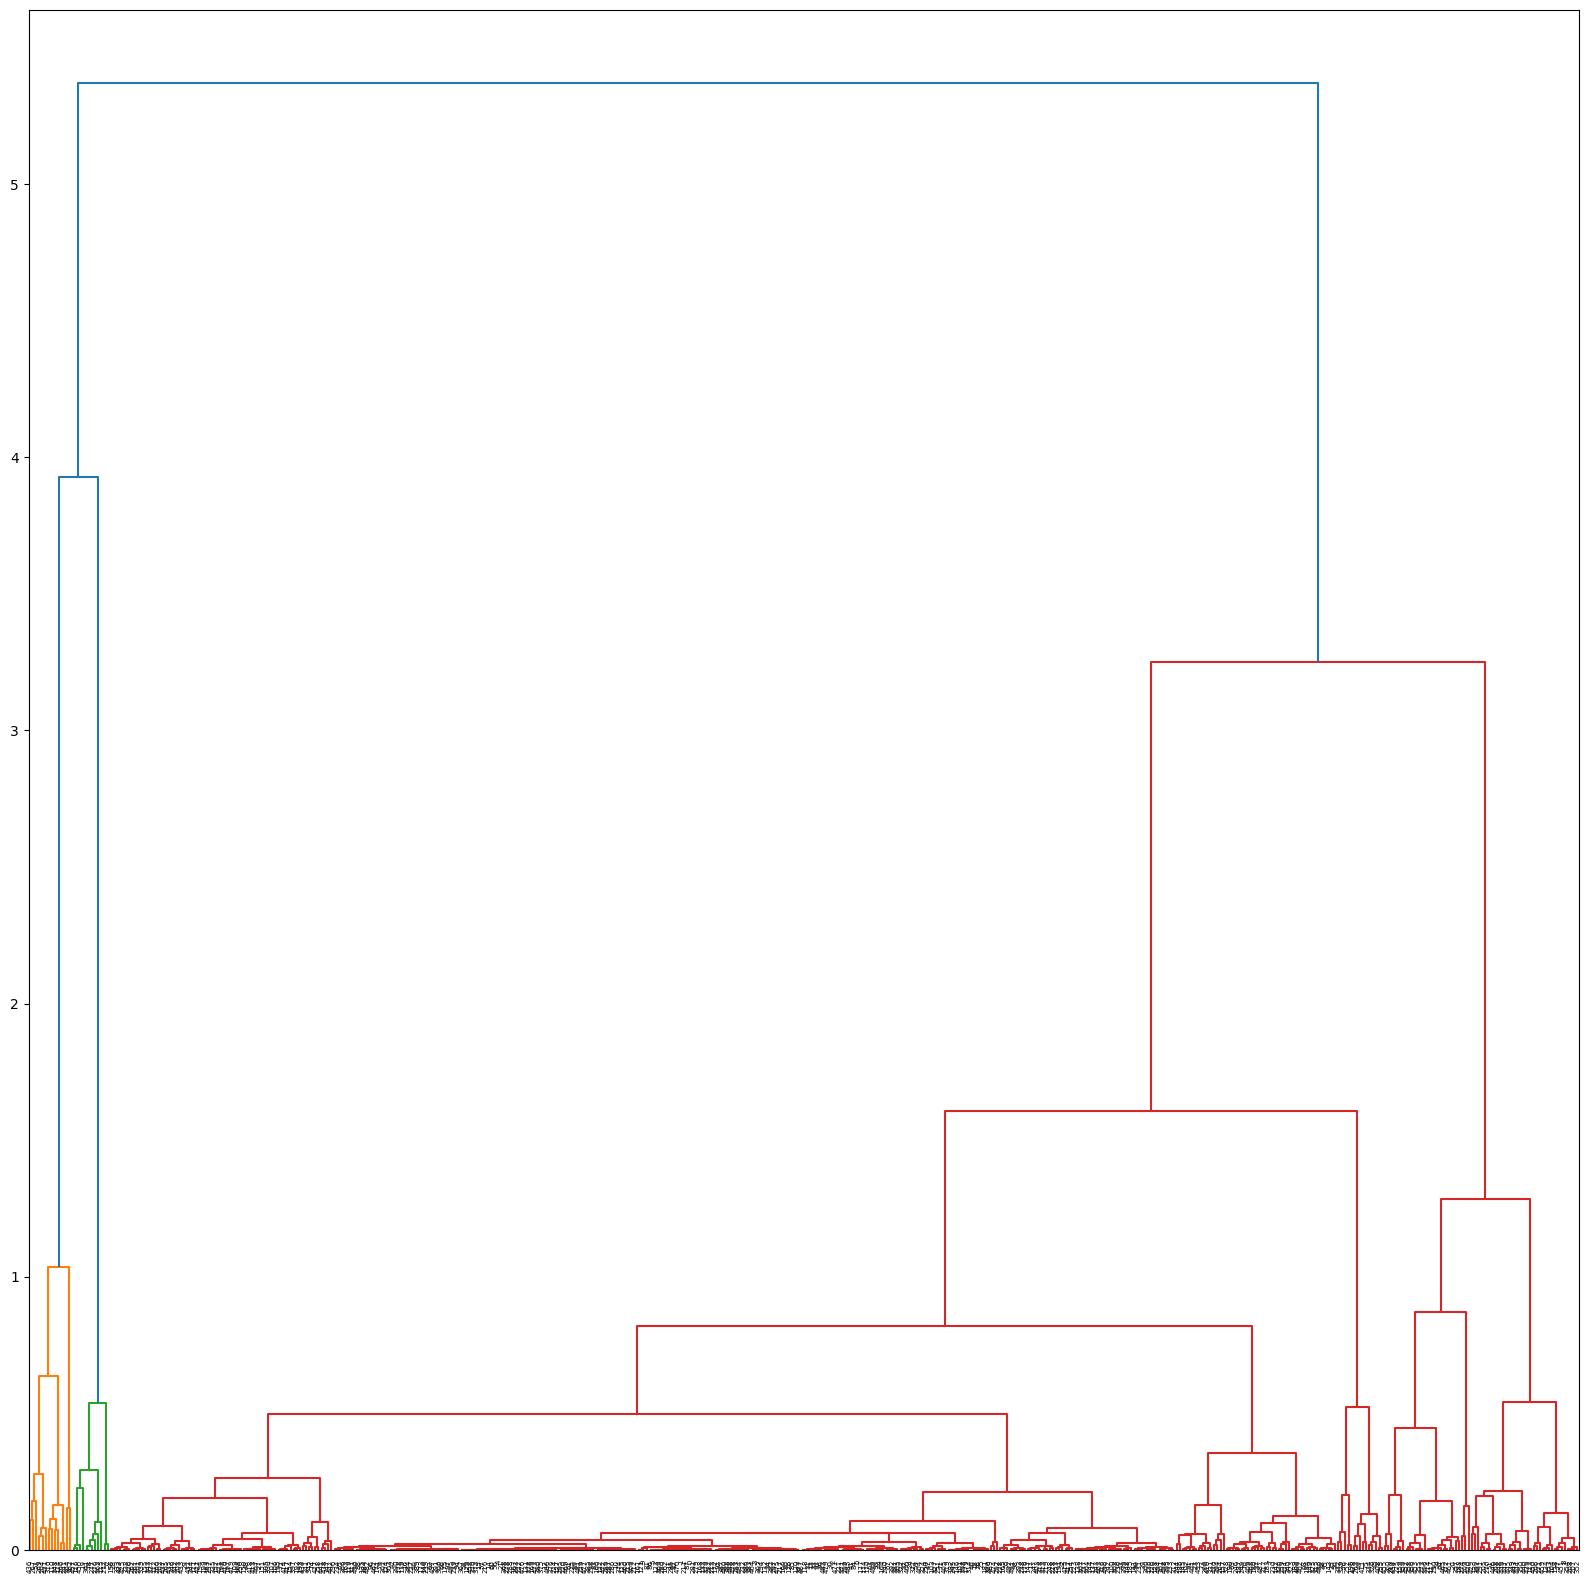

In [66]:
import scipy.cluster.hierarchy as shc

print(data_pca)

linked_mat = shc.linkage(data_pca, "ward")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()

In [67]:
import time
from sklearn import cluster
# set distance_threshold(0 ensures we compute the full tree)
# tps1 = time.time()
# model = cluster.AgglomerativeClustering(distance_threshold = 5 , \
#     linkage = "ward" , n_clusters = None)
# model = model.fit(data_pca)
# tps2 = time.time()

# labels = model.labels_
# nb_clusters = model.n_clusters_
# leaves = model.n_leaves_
# print("nb clusters =", nb_clusters ,", nb feuilles =", leaves , "runtime =", round (( tps2 - tps1) * 1000 , 2) ," ms")

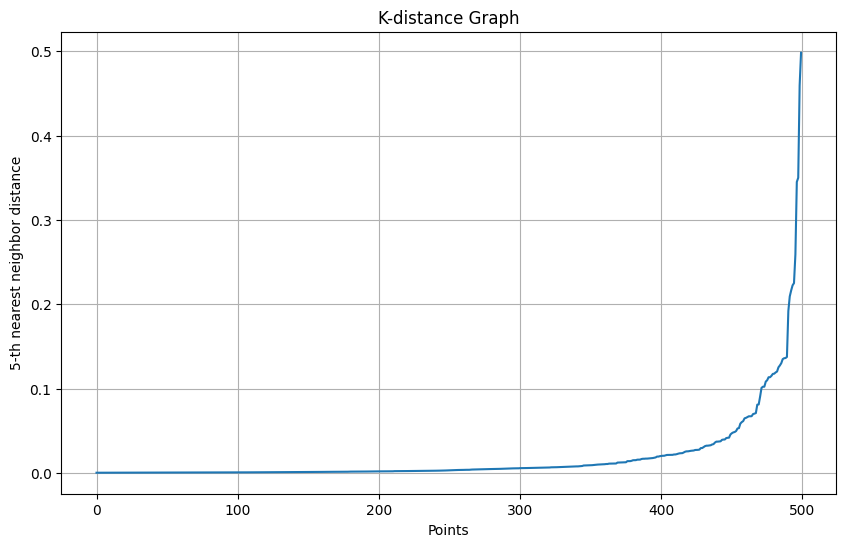

In [68]:
from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.grid()
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(data_pca, k=5)

Cluster
-1     99
 0    401
Name: count, dtype: int64


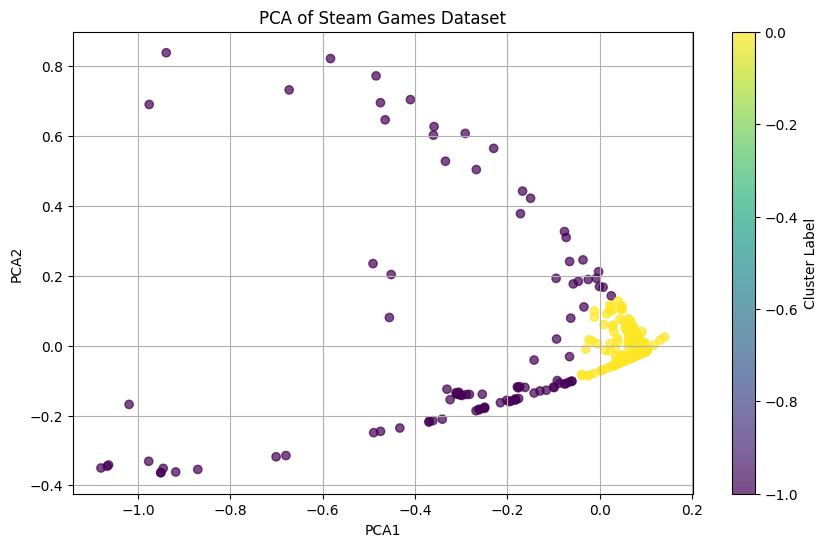

In [74]:
# Essaie avec DBSCAN
from sklearn.cluster import DBSCAN
tps1 = time.time()
dbscan_model = DBSCAN(eps=0.06, min_samples=30)
dbscan_model.fit(data_pca)
tps2 = time.time()

labels = dbscan_model.labels_

df_clustered = df.copy()
df_clustered['Cluster'] = labels

cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print(cluster_counts)
nb_clusters = cluster_counts.shape[0]
df_clustered.head(100)

## Plot les clusters selon les composants PCA
## Visualisation 2D 
plt.figure(figsize=(10,6))
# for i, txt in enumerate(df_reduced['name']):
#     plt.annotate(txt, (df_reduced['PCA1'][i], df_reduced['PCA2'][i]), fontsize=8, alpha=0.6)
# Coloring by cluster
scatter = plt.scatter(df_reduced['PCA1'], df_reduced['PCA2'], c=df_clustered['Cluster'], cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')
plt.title("PCA of Steam Games Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid()
plt.show()

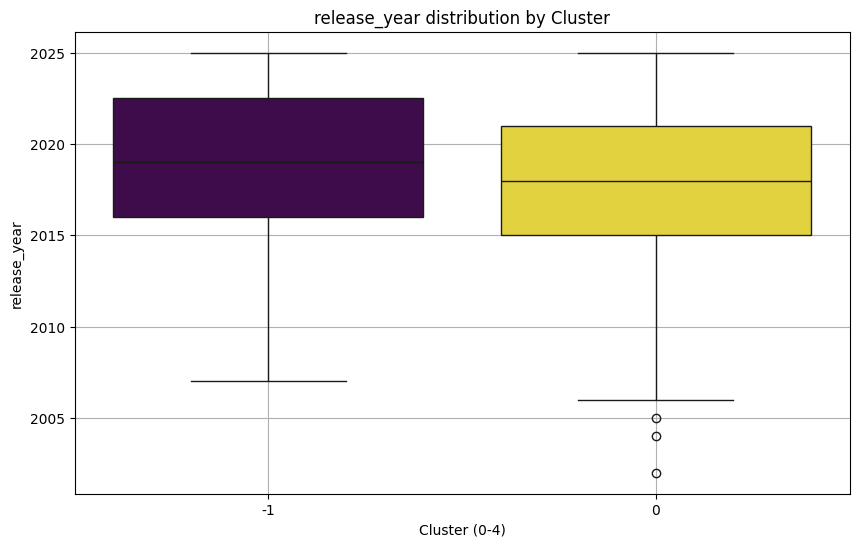

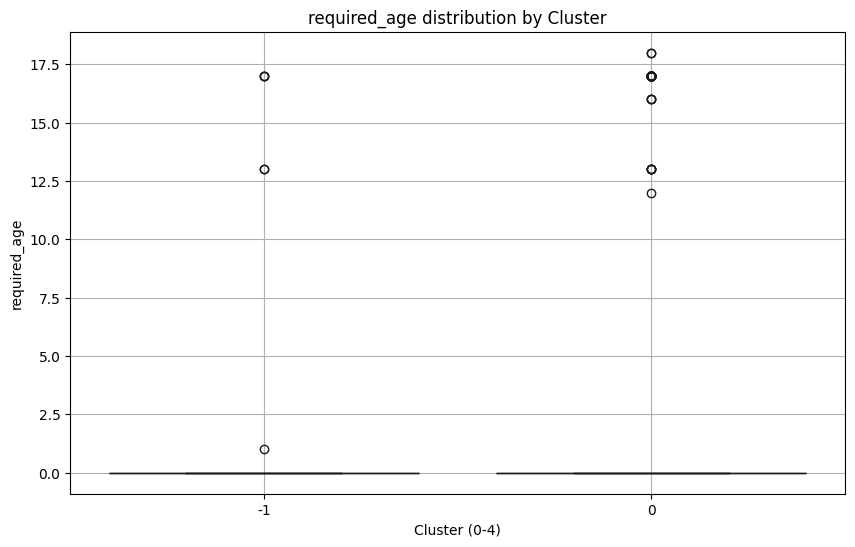

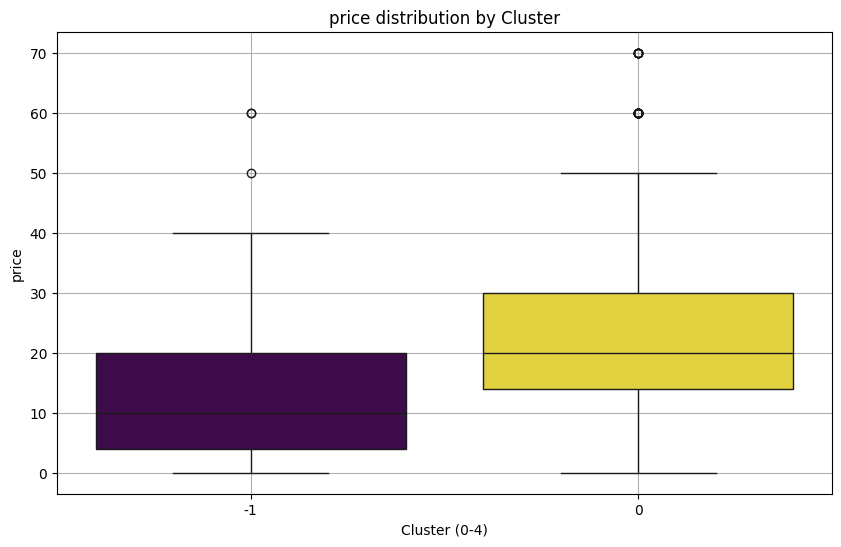

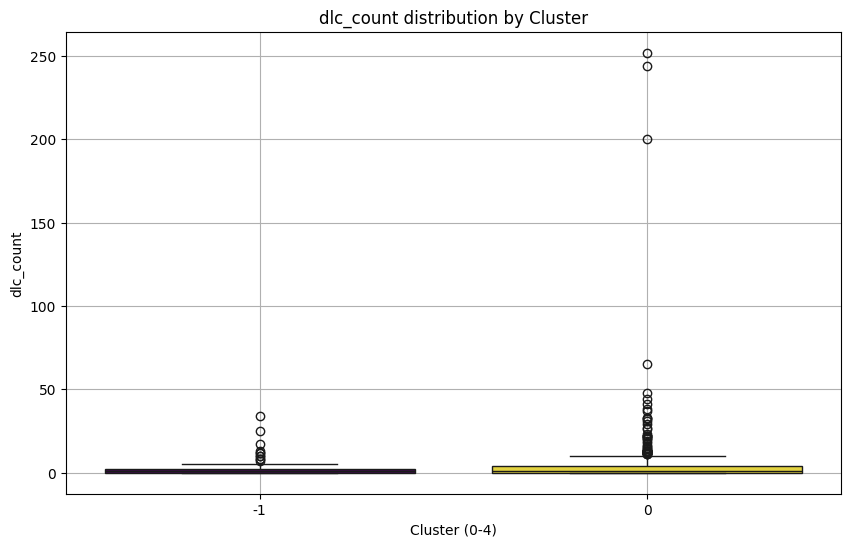

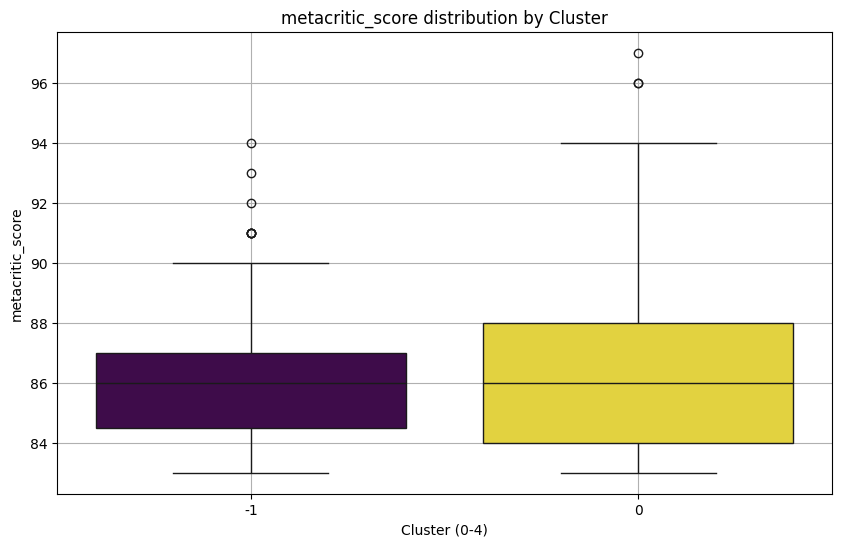

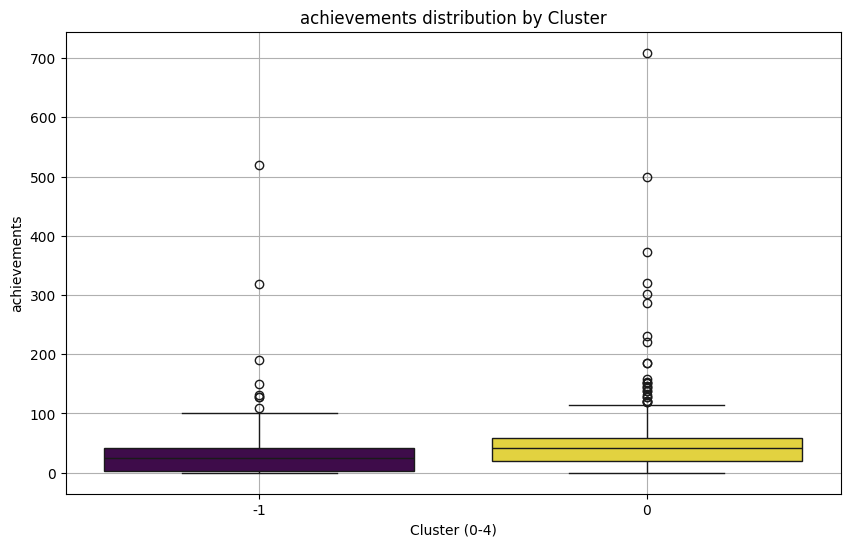

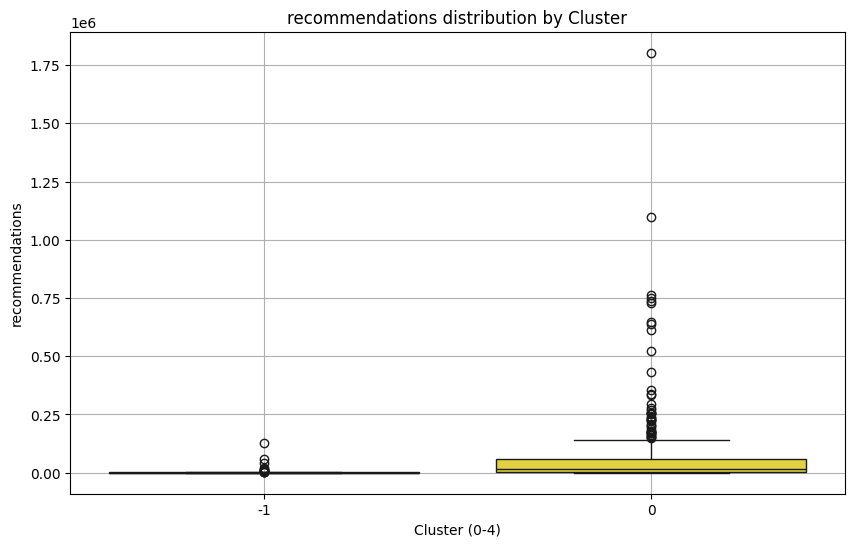

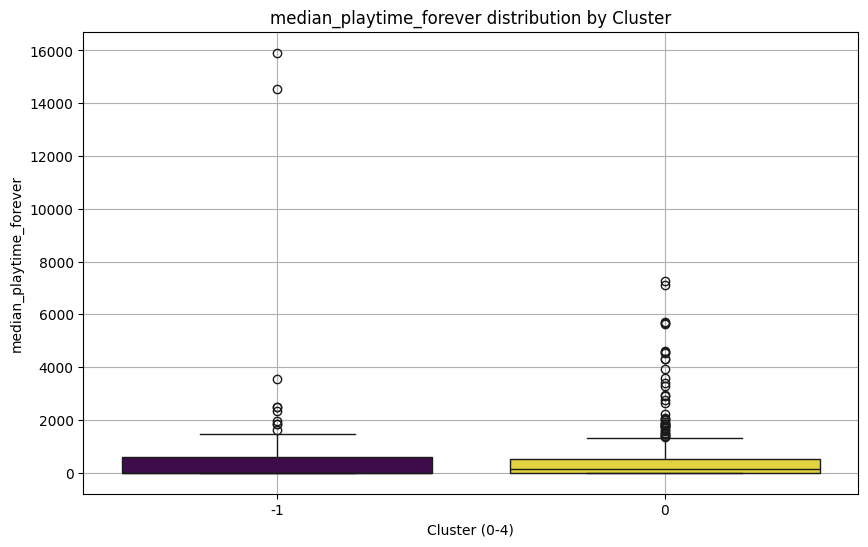

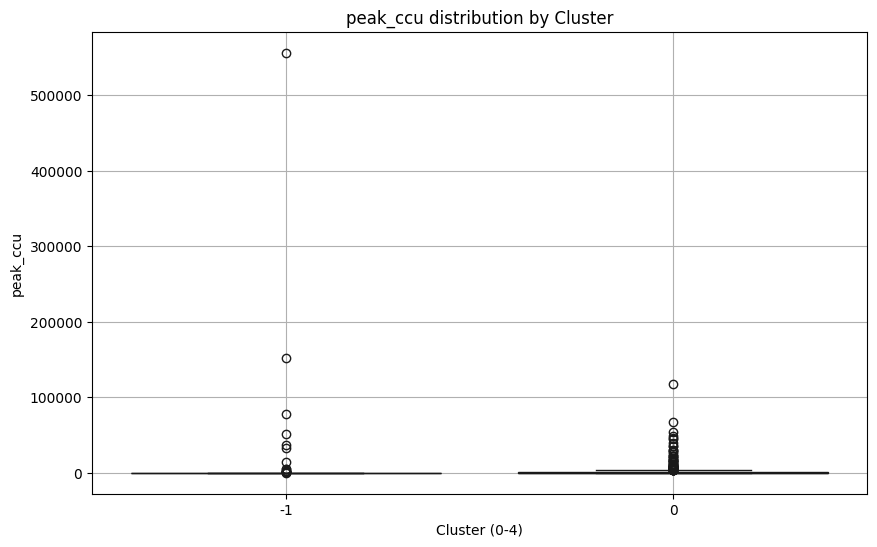

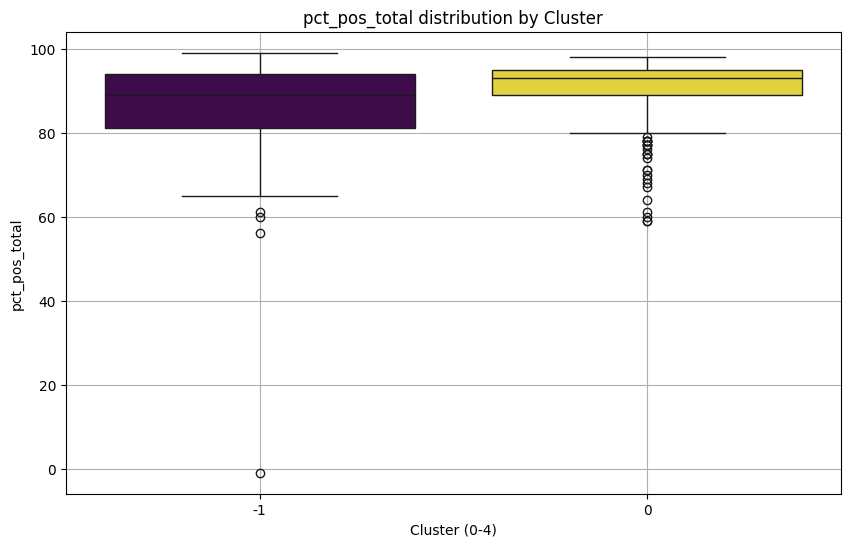

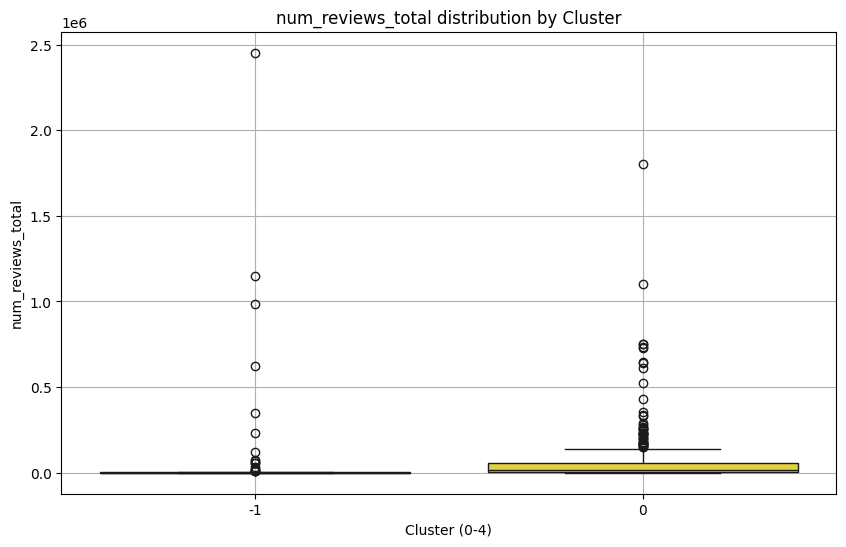

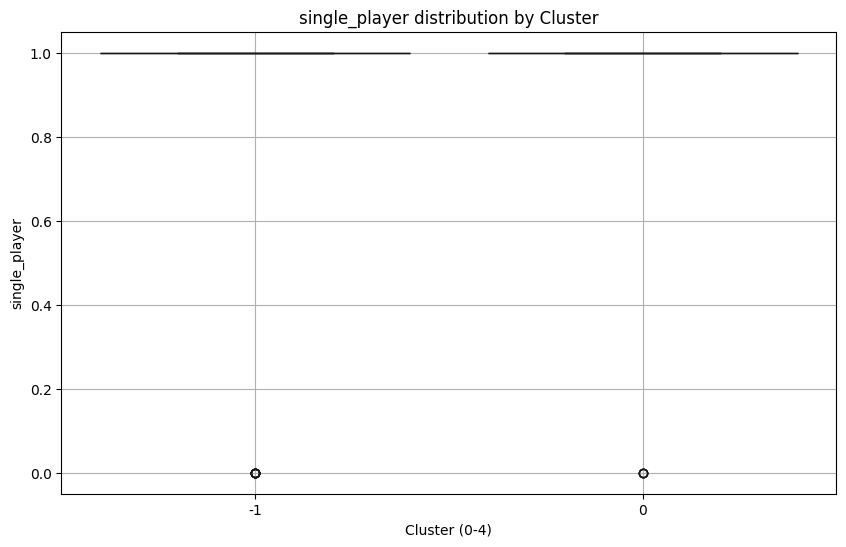

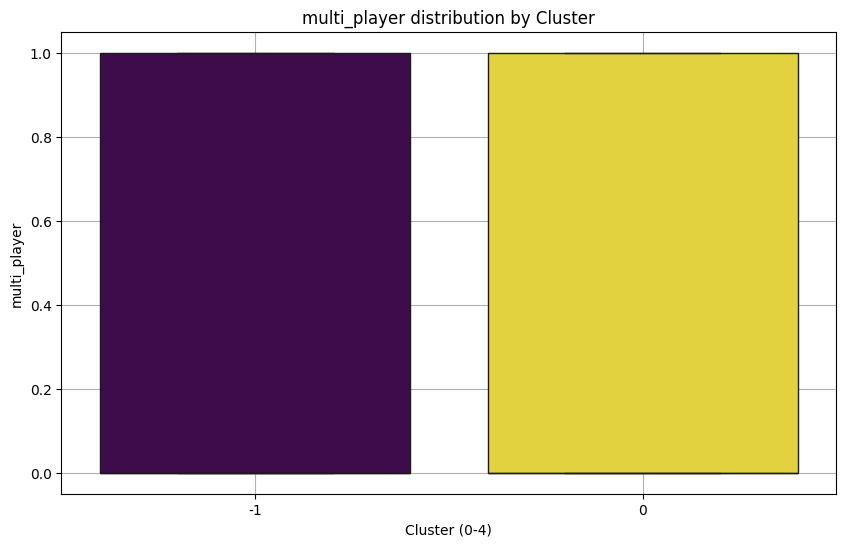

In [70]:
import seaborn as sns

for feature in features:
    # --- 2. Create the Plot ---
    plt.figure(figsize=(10, 6))

    # The Box Plot Command
    sns.boxplot(x='Cluster', y=feature, data=df_clustered, hue='Cluster', palette='viridis', legend=False)

    # Labeling
    plt.title(f'{feature} distribution by Cluster')
    plt.xlabel('Cluster (0-4)')
    plt.ylabel(feature)
    plt.grid()
    plt.show()

In [71]:
## Afficher les 10 jeux les plus recommandés par cluster
top_games = df_clustered[df_clustered['Cluster'] == -1].sort_values(by='recommendations', ascending=False).head(20)
print(f"Top 10 recommended games in Noise Cluster:")
print(top_games[['name', 'recommendations', 'pct_pos_total', 'price']])
print("\n")
for cluster_num in range(nb_clusters):
    top_games = df_clustered[df_clustered['Cluster'] == cluster_num].sort_values(by='recommendations', ascending=False).head(20)
    print(f"Top 10 recommended games in Cluster {cluster_num}:")
    print(top_games[['name', 'recommendations', 'pct_pos_total', 'price']])
    print("\n")

Top 10 recommended games in Noise Cluster:
                                                 name  recommendations  \
19                                          Destiny 2           127458   
335                      Kingdom Come: Deliverance II            56822   
5                                     Team Fortress 2            41587   
323                                        Battlerite            21530   
2                                              Dota 2            14337   
1108                            Football Manager 2022            13758   
1428                                   Desperados III             9892   
1483                                     Caves of Qud             9360   
38                                          Paladins®             8854   
490                                        EVE Online             7580   
1199                            Football Manager 2019             7394   
2386                      Wasteland 2: Director's Cut             462